### Cellule 1 — Imports

In [6]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import pandas as pd
import numpy as np

### Cellule 2 — Définir les chemins

In [8]:
DATA_DIR = Path('../data/raw/Rock Data')
TRAIN_DIR = DATA_DIR / 'train'
VALID_DIR = DATA_DIR / 'valid'
TEST_DIR = DATA_DIR / 'test'
CLASSES = sorted(os.listdir(TRAIN_DIR))
print(f'Classes trouvées : {CLASSES}')

Classes trouvées : ['Basalt', 'Clay', 'Conglomerate', 'Diatomite', 'Shale-(Mudstone)', 'Siliceous-sinter', 'chert', 'gypsum', 'olivine-basalt']


### Cellule 3 — Distribution des classes

In [27]:
counts = {cls: len(os.listdir(TRAIN_DIR / cls)) for cls in CLASSES}
df = pd.DataFrame(counts.items(), columns=['Classe', 'Train'])

print(df)

# sns.barplot(data=df, x='Classe', y='Train')
# plt.title('Distribution des classes — Train')
# plt.xticks(rotation=45); plt.tight_layout(); plt.show()

             Classe  Train
0            Basalt    432
1              Clay    453
2      Conglomerate    447
3         Diatomite    405
4  Shale-(Mudstone)    396
5  Siliceous-sinter    381
6             chert    405
7            gypsum    393
8    olivine-basalt    375


### Cellule 4 — Visualisation d'échantillons

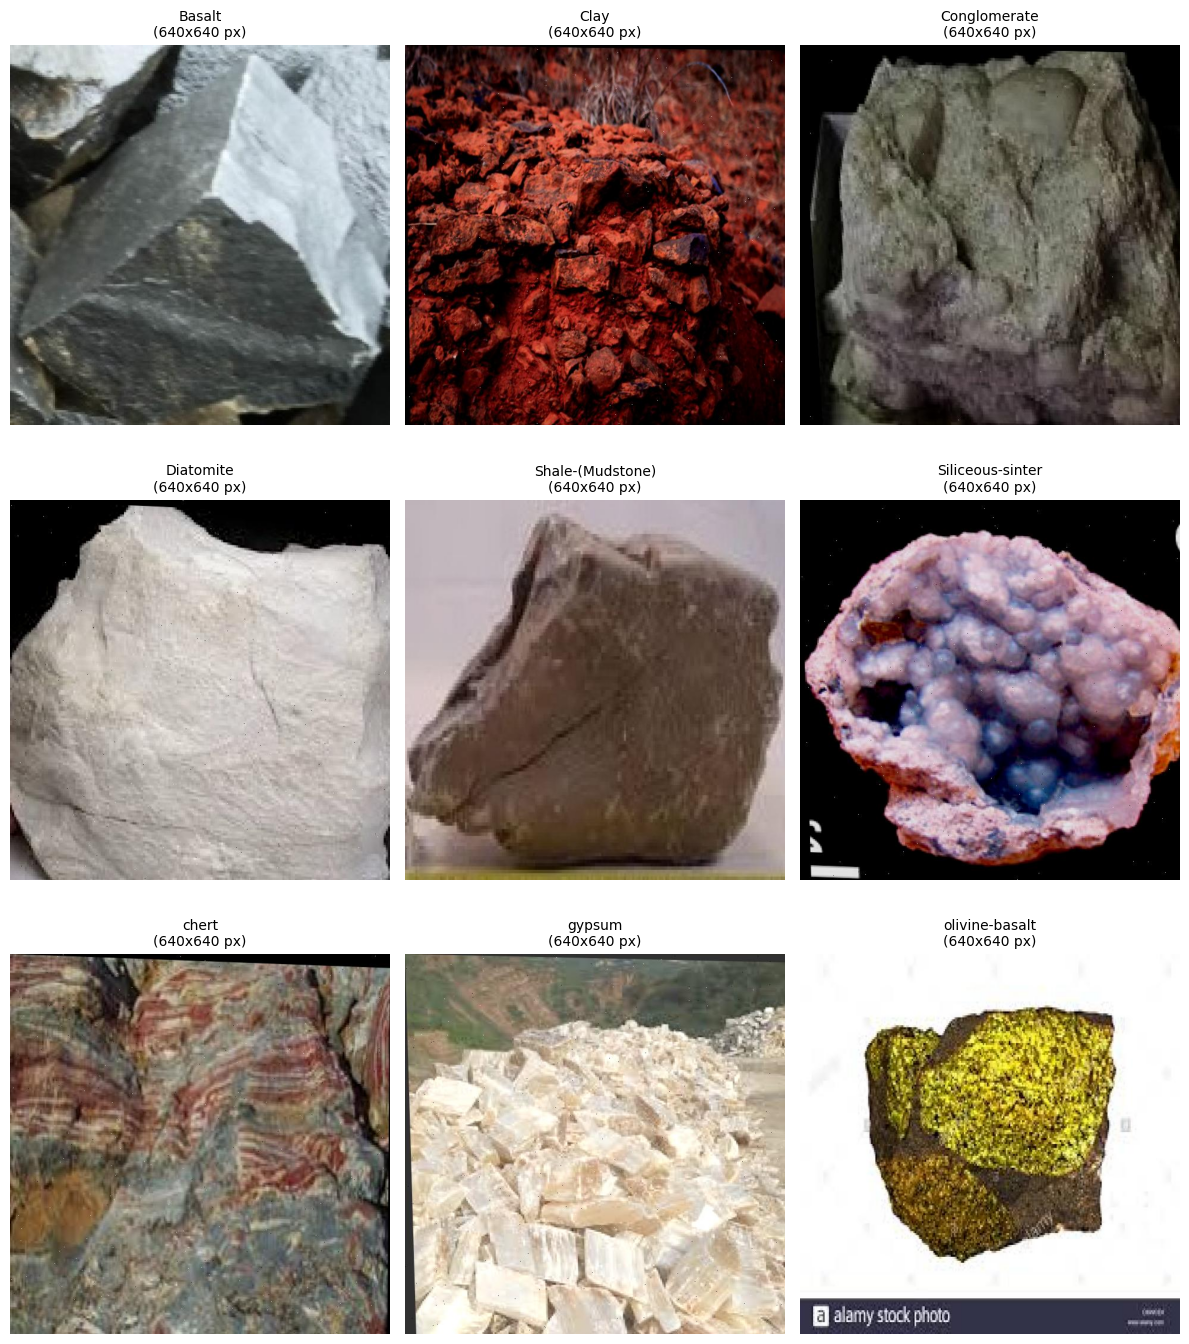

In [21]:
import random

fig, axes = plt.subplots(3, 3, figsize=(12, 14))

for ax, cls in zip(axes.flat, CLASSES):
    # 1. Lister toutes les images de la classe
    all_images = list((TRAIN_DIR / cls).iterdir())
    
    # 2. Choisir une image AU HASARD au lieu de toujours prendre la [0]
    random_img_path = random.choice(all_images)
    
    # 3. Ouvrir l'image et récupérer sa taille (résolution)
    img = Image.open(random_img_path)
    width, height = img.size
    
    # 4. Afficher l'image
    ax.imshow(img)
    
    # 5. Ajouter le nom de la classe ET la résolution dans le titre
    ax.set_title(f"{cls}\n({width}x{height} px)", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Conclusion

## 1.3 Conclusion de l'Exploration des Données (Bilan Phase 1)

Suite à l'analyse visuelle et statistique du dataset, voici les réponses aux questions de contrôle :

* **Quelle classe a le plus d'images ? Le moins ?** La classe avec le plus d'images est **Clay** (453 images). La classe avec le moins d'images est **olivine-basalt** (375 images).
* **L'écart entre min et max est-il supérieur à 2x ?** **Non.** Le ratio est d'environ 1.2. Le dataset est naturellement bien équilibré, ce qui nous évitera d'avoir à appliquer des poids spécifiques à notre fonction de perte (Loss) lors de l'entraînement.
* **Y a-t-il des images corrompues ou non-lisibles ?** **Non.** La boucle de chargement `Image.open()` a pu lire les échantillons sans lever d'erreur, confirmant l'intégrité globale des fichiers.
* **Les images sont-elles toutes en couleur (RGB) ?** **Oui**, l'inspection visuelle confirme que les images sont en couleur. De plus, toutes les images affichées possèdent une résolution standardisée de 640x640 pixels.
* **Basalt et Olivine-basalt se ressemblent-ils visuellement ?** Bien qu'elles partagent une base sombre (roche volcanique), l'Olivine-basalt se distingue souvent par la présence de cristaux verdâtres (l'olivine). Cependant, le dataset est "bruité" (présence d'échelles, de mains, de filigranes "alamy", et d'arrière-plans variés). Une phase d'augmentation des données (Data Augmentation) sera cruciale dans la Phase 2 pour forcer le modèle à se concentrer sur la texture de la roche.